In [1]:
import pypsa
import fbmc  # noqa: F401  not unused; registers pypsa.Network.fbmc accessor
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import networkx as nx


In [2]:
nodal_net = pypsa.Network("base_s_9_elec_.nc")

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, lines, links, loads, storage_units


In [3]:
#nodal_net.remove(
#    "Generator",
#    nodal_net.generators.index[nodal_net.generators.index.str.contains("load_shedding", case=False, na=False)]
#)

In [4]:
nodal_net.generators.keys

<bound method NDFrame.keys of                  bus control type        p_nom  p_nom_mod  p_nom_extendable  \
Generator                                                                     
BE0 0 CCGT     BE0 0   Slack       6634.200000        0.0             False   
BE0 0 OCGT     BE0 0      PQ          0.000000        0.0              True   
BE0 0 biomass  BE0 0      PQ        113.000000        0.0             False   
BE0 0 nuclear  BE0 0      PQ       4096.000000        0.0             False   
BE0 0 oil      BE0 0      PQ        130.200000        0.0             False   
...              ...     ...  ...          ...        ...               ...   
BE0 0 0 solar  BE0 0      PQ        937.600000        0.0              True   
DE0 0 0 solar  DE0 0      PQ       5358.910412        0.0              True   
DE0 4 0 solar  DE0 4      PQ       6630.417502        0.0              True   
NL0 0 0 solar  NL0 0      PQ       1694.000000        0.0              True   
NL0 1 0 solar  NL0 1  

/var/folders/cn/l4_9msnj2pb5tkz_l18sbgdh0000gn/T/ipykernel_16980/2638874217.py:5: DeprecatedWarning: plot is deprecated as of 0.34 and will be removed in 1.0. Use `n.plot.map()` as a drop-in replacement instead.
  nodal_net.plot(


{'nodes': {'Bus': <matplotlib.collections.PatchCollection at 0x14d4f5bd0>},
 'branches': {'Link': <matplotlib.collections.LineCollection at 0x14d5011d0>,
  'Line': <matplotlib.collections.LineCollection at 0x14d51c090>},
 'flows': {}}

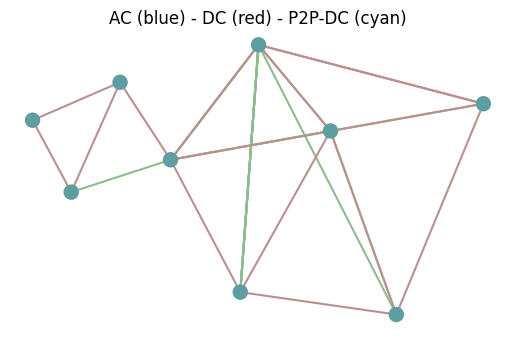

In [5]:
line_color = nodal_net.lines.bus0.map(nodal_net.buses.carrier).map(
    lambda ct: "r" if ct == "DC" else "b"
)

nodal_net.plot(
    title="AC (blue) - DC (red) - P2P-DC (cyan)",
    jitter=0.4,
)

In [3]:
nodal_net.buses.rename(columns={"country": "zone_name"}, inplace=True)

In [4]:
bus_zone_map = nodal_net.buses['zone_name']
zonal_net = nodal_net.fbmc.to_zonal(bus_zone_map)

Skipping missing attribute loss


In [5]:
import fbmc.input_network_conversions.network_conversion as nc

In [5]:
config = fbmc.FBMCConfig(
    base_case_strategy=fbmc.BaseCaseStrategy.NODAL_OPTIMUM,
    add_security_constraints=False,
    gsk_strategy=fbmc.GSKStrategy.CURRENT_GENERATION,
    security_constraint_bodf_size_threshold=0.1,
    min_ram=0.1,
    reliability_margin_factor=0.1,
    advanced_hybrid_coupling_flag= True,
    solver_kwargs={'solver_name': 'gurobi', 'OutputFlag': 0},
)

zonal_net.fbmc.create_model(nodal_net, config=config)
zonal_net.model.solve(**config.solver_kwargs)
result = zonal_net.fbmc.results()
print(result)

INFO:linopy.model: Solve problem using Gurobi solver
INFO:linopy.model:Solver options:
 - OutputFlag: 0
INFO:linopy.io: Writing time: 0.12s


Set parameter Username


INFO:gurobipy:Set parameter Username


Set parameter LicenseID to value 2838876


INFO:gurobipy:Set parameter LicenseID to value 2838876


...

INFO:gurobipy:Reading time = 0.01 seconds


obj: 6888 rows, 3154 columns, 12933 nonzeros


INFO:gurobipy:obj: 6888 rows, 3154 columns, 12933 nonzeros
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 3154 primals, 6888 duals
Objective: 6.40e+07
Solver model: available
Solver message: 2

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Line-ext-s-lower, Line-ext-s-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, Kirchhoff-Voltage-Law, StorageUnit-energy_balance were not assigned to the network.
INFO:root:Determined 1 sub-networks in the base case nodal network.
INFO:root:Created optimization model without meshed split.


mask: None


AttributeError: 'NoneType' object has no attribute 'shape'

<Axes: xlabel='Generator'>

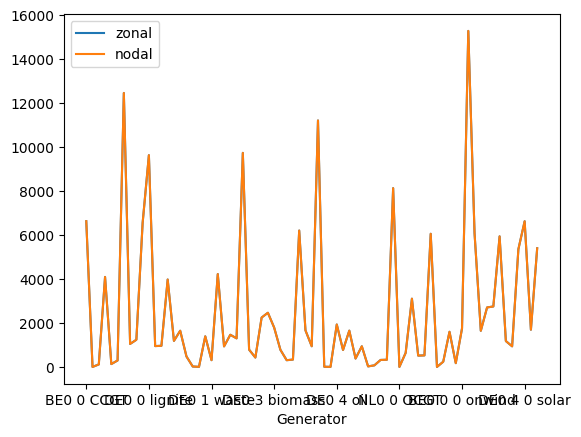

In [14]:
df = pd.DataFrame()
df["zonal"] = zonal_net.generators.p_nom_opt
df["nodal"] = nodal_net.generators.p_nom_opt
df.plot()

In [20]:
result.zonal_net.model.constraints['CNEC-upper-RAM-subnet-0'].sel(snapshot=zonal_net.snapshots[10]).sel(cnec="2")

Constraint `CNEC-upper-RAM-subnet-0`
------------------------------------
-0.187 Zone-p[2013-03-01 10:00:00, DE] ≤ 12474.449599744848

In [12]:
con = result.zonal_net.model.constraints['Zone-definition'].sel(snapshot=zonal_net.snapshots[0]).sel(Zone="BE")
print(str(con))

Constraint `Zone-definition`
----------------------------
+1 Zone-p[2013-03-01 00:00:00, BE] - 1 Generator-p[2013-03-01 00:00:00, BE0 0 CCGT] - 1 Generator-p[2013-03-01 00:00:00, BE0 0 OCGT] ... -1 StorageUnit-p_dispatch[2013-03-01 00:00:00, BE0 0 battery] + 1 StorageUnit-p_store[2013-03-01 00:00:00, BE0 0 battery] + 1 Link-p[2013-03-01 00:00:00, relation/8193755-320-DC] = -10150.999992370605


In [11]:
with open("constraint.txt", "w") as f:
    f.write(str(con))

NameError: name 'con' is not defined

In [10]:
result.zonal_net.model.constraints['CNEC-lower-RAM-subnet-0'].sel(snapshot=zonal_net.snapshots[0])

Constraint `CNEC-lower-RAM-subnet-0` [cnec: 15]:
------------------------------------------------
[0]: -0.5116 Zone-p[2013-03-01 00:00:00, DE] - 0.5992 Zone-p[2013-03-01 00:00:00, NL]  ≥ -2798.284081149478
[1]: -0.4884 Zone-p[2013-03-01 00:00:00, DE] - 0.4008 Zone-p[2013-03-01 00:00:00, NL]  ≥ -3314.885321116425
[10]: +0.03118 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -4727.512806574352
[11]: +0.07794 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -26193.84472864287
[12]: -0.03624 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -6568.791078020348
[13]: +0.03494 Zone-p[2013-03-01 00:00:00, DE]                                         ≥ -6542.823244299205
[14]: -0.5116 Zone-p[2013-03-01 00:00:00, DE] + 0.1362 Zone-p[2013-03-01 00:00:00, NL] ≥ -9552.020435697692
		...
[3]: -0.2697 Zone-p[2013-03-01 00:00:00, DE]                                           ≥ -11238.855601234194
[4]: -0.1454 Zone-p[2013-03-01 

In [131]:
result.fbmc_parameters['0'].cnecs.outage.to_pandas()

AttributeError: 'DataArray' object has no attribute 'outage'

In [139]:
d = nodal_net.buses.apply(lambda row: (row["x"], row["y"]), axis=1).to_dict()
d

{'BE0 0': (5.139284238571429, 50.68561860171428),
 'DE0 0': (7.239637820731708, 51.37830108810975),
 'DE0 1': (11.40887984148936, 48.80724648893617),
 'DE0 2': (13.094428980806452, 52.452413288870964),
 'DE0 3': (9.25141665419355, 53.4362586617742),
 'DE0 4': (8.705499178787878, 49.17755361858586),
 'DE0 5': (10.195867937435898, 51.594052309487175),
 'NL0 0': (4.481626574117647, 52.059696368235294),
 'NL0 1': (6.183861166470588, 52.56340226882353)}

In [140]:
nodal_net.buses[["x","y"]].to_dict(orient = 'index')

{'BE0 0': {'x': 5.139284238571429, 'y': 50.68561860171428},
 'DE0 0': {'x': 7.239637820731708, 'y': 51.37830108810975},
 'DE0 1': {'x': 11.40887984148936, 'y': 48.80724648893617},
 'DE0 2': {'x': 13.094428980806452, 'y': 52.452413288870964},
 'DE0 3': {'x': 9.25141665419355, 'y': 53.4362586617742},
 'DE0 4': {'x': 8.705499178787878, 'y': 49.17755361858586},
 'DE0 5': {'x': 10.195867937435898, 'y': 51.594052309487175},
 'NL0 0': {'x': 4.481626574117647, 'y': 52.059696368235294},
 'NL0 1': {'x': 6.183861166470588, 'y': 52.56340226882353}}

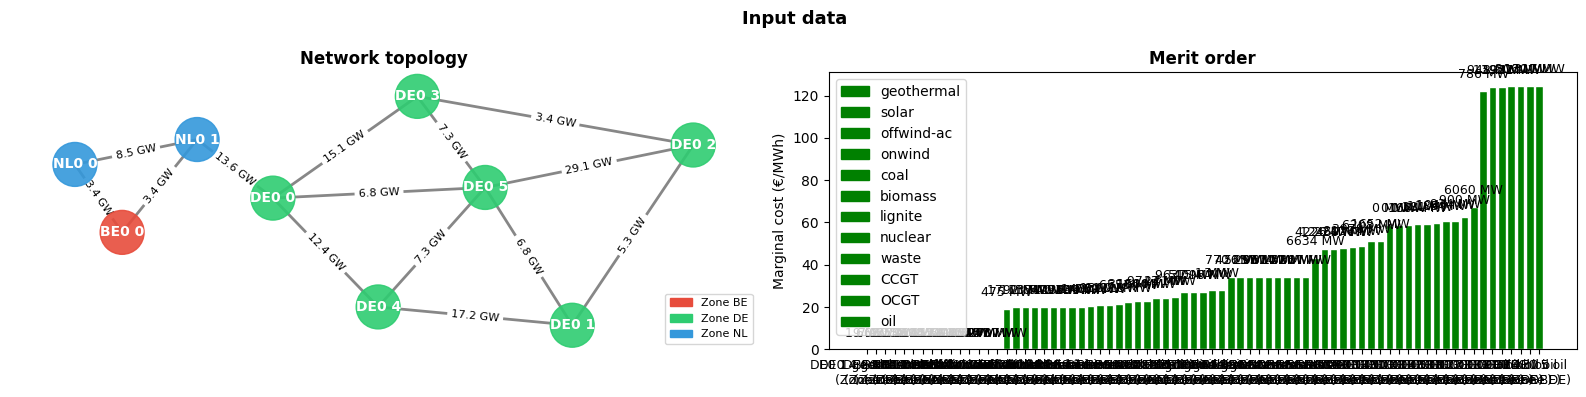

In [8]:
zone_colors   = {'BE': '#E74C3C', 'DE': '#2ECC71', 'NL': '#3498DB'}
carrier_colors = {'CCGT': "green", 'OCGT':"green", 'biomass':"green", 'nuclear':"green", 'oil':"green", 'waste':"green", 'coal':"green", 'lignite':"green", 'geothermal':"green", 'onwind':"green", 'offwind-ac':"green", 'solar':"green"}

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Network topology
ax = axes[0]
#pos = {'A1': (-2, 0), 'B1': (0, 1.2), 'B2': (0, -1.2), 'C1': (2, 0)}
pos = nodal_net.buses.apply(lambda row: (row["x"], row["y"]), axis=1).to_dict()
G = nx.Graph()
G.add_nodes_from(nodal_net.buses.index)
for l in nodal_net.lines.itertuples():
    G.add_edge(l.bus0, l.bus1, s_nom=l.s_nom)

nx.draw_networkx_nodes(G, pos, ax=ax,
    node_color=[zone_colors[nodal_net.buses.loc[b, 'zone_name']] for b in G.nodes()],
    node_size=1000, alpha=0.9)
nx.draw_networkx_labels(G, pos, ax=ax, font_weight='bold', font_color='white', font_size=10)
nx.draw_networkx_edges(G, pos, ax=ax,
    width=2, edge_color='#555', alpha=0.7)
nx.draw_networkx_edge_labels(G, pos,
    {(u, v): f"{round(G[u][v]['s_nom']/1000,1)} GW" for u, v in G.edges()}, font_size=8, ax=ax)
ax.legend(handles=[mpatches.Patch(color=c, label=f'Zone {z}') for z, c in zone_colors.items()],
          loc='lower right', fontsize=8)
ax.set_title('Network topology', fontweight='bold')
ax.axis('off')

# Merit order
ax = axes[1]
gens = nodal_net.generators.copy()
gens['zone'] = nodal_net.buses.loc[gens['bus'], 'zone_name'].values
gens = gens.sort_values('marginal_cost')
ax.bar(range(len(gens)), gens['marginal_cost'],
       color=[carrier_colors[c] for c in gens['carrier']], edgecolor='white')
for i, (_, row) in enumerate(gens.iterrows()):
    ax.text(i, row['marginal_cost'] + 6, f"{int(row['p_nom'])} MW", ha='center', fontsize=9)
ax.set_xticks(range(len(gens)))
ax.set_xticklabels([f"{idx}\n(Zone {row['zone']})" for idx, row in gens.iterrows()], fontsize=9)
ax.set_ylabel('Marginal cost (€/MWh)')
ax.set_title('Merit order', fontweight='bold')
ax.legend(handles=[mpatches.Patch(color=carrier_colors[c], label=c) for c in gens['carrier'].unique()])


plt.suptitle('Input data', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

FBMCResult
  zonal_net: Unnamed Network | snapshots=24 | components=[Bus:3, Generator:73, Load:9, Link:1, StorageUnit:9]
  base_case: Unnamed Network | snapshots=24 | components=[Bus:9, Generator:73, Load:9, Line:15, Link:14, StorageUnit:9, SubNetwork:1]
  net_positions: DataFrame(24, 3)
  dispatch_results: DispatchResult object with attrs: 
  generators_p: (24, 73) snapshots x generators, 
  storage_units_p: (24, 9) snapshots x storage units, 
  links_p0: (24, 1) snapshots x links, 
  storage_levels: (24, 9) snapshots x storage levels, 
  water_values: (24, 9) snapshots x water values
  fbmc_parameters: 1 subnet(s) [0]

In [11]:
from fbmc.post_processing.main import process_results

In [132]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/3-zones/results", config = config)

NameError: name 'process_results' is not defined

In [133]:
zonal_price = -slack_zone_dual_ser + (z_ptdf * cnec_upper_ram_dual).sum(dim="cnec")

NameError: name 'slack_zone_dual_ser' is not defined

In [134]:
nodal_net.buses_t.marginal_price

Bus,BE0 0,DE0 0,DE0 1,DE0 2,DE0 3,DE0 4,DE0 5,NL0 0,NL0 1
snapshot,,,,,,,,,
2013-03-01 00:00:00,47.609796,47.609796,48.837673,24.321079,62.795092,34.122731,47.620187,47.609796,47.609796
2013-03-01 01:00:00,47.609796,47.609796,48.837673,24.321079,62.795092,34.122731,47.620187,47.609796,47.609796
2013-03-01 02:00:00,47.609796,47.609796,48.837673,24.321079,62.795092,34.122731,47.620187,47.609796,47.609796
2013-03-01 03:00:00,47.609796,47.609796,48.837673,24.321079,62.795092,51.125700,47.620187,47.609796,47.609796
2013-03-01 04:00:00,47.609796,47.609796,55.532750,24.321079,62.795092,51.125700,51.207180,47.609796,47.609796
2013-03-01 05:00:00,48.225550,47.609796,59.720388,24.321079,62.795092,51.125700,51.207180,48.225550,48.225550
2013-03-01 06:00:00,48.225550,47.609796,62.804807,24.321079,62.795092,51.125700,51.207180,48.225550,48.225550
2013-03-01 07:00:00,48.225550,47.609796,62.804807,24.321079,62.795092,51.125700,59.356298,48.225550,48.225550
2013-03-01 08:00:00,48.225550,47.609796,62.804807,24.321079,62.795092,51.125700,59.356298,48.225550,48.225550


In [135]:
linopy_network = pypsa.Network("results/linopy_model.nc")

KeyError: 'name'

In [10]:
from src.redispatch.main import run_redispatch
redispatch_results = run_redispatch(nodal_net, result.dispatch_results, security_constrained_flag=False)

ValueError: conflicting sizes for dimension 'Generator': length 73 on the data but length 82 on coordinate 'Generator'

In [137]:
nodal_net

PyPSA Network 'Unnamed Network'
-------------------------------
Components:
 - Bus: 9
 - Carrier: 16
 - Generator: 82
 - Line: 15
 - Link: 14
 - Load: 9
 - StorageUnit: 9
 - SubNetwork: 1
Snapshots: 24

In [138]:
process_results(result, rd_cost= None, rd_dispatch= None, save_path = "/Users/ng-work/Models/pypsa-fbmc/nathan_tests/3-zones/results", config = config)

NameError: name 'process_results' is not defined

In [18]:
nodal_net.buses_t.p.sum()

Bus
BE0 0    3.414645e+04
DE0 0    6.174708e+04
DE0 1    3.387743e-09
DE0 2    4.745466e-11
DE0 3    2.163908e-10
DE0 4   -8.976600e-13
DE0 5   -1.121477e-09
NL0 0    2.961647e+03
NL0 1   -9.885518e+04
dtype: float64